In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
import matplotlib.pyplot as plt

# Data Preprocessing

In [40]:
dt = pd.read_csv("Main_Dataset.csv")
dt.shape

(2045, 15)

In [41]:
dt.head()

,protocol,total_packets,syn(common),"[syn,ack](common)",final_ack(common),syn_ratio(common),syn_ack_rate(common),ack_ratio(common),get_count,get_ratio,avg_pkt_size,unique_uri_ratio,avg_session_duration,num_contributing_ips,label
0,TCP,4,0,0,0,0.0,0.0,0.0,0,0.0,103.00,0.0,0.338,2,Normal
1,TCP,25,0,0,0,0.0,0.0,0.0,0,0.0,400.92,0.0,0.986,2,Normal
2,TCP,22,0,0,0,0.0,0.0,0.0,0,0.0,115.41,0.0,2.186,2,Normal
3,TCP,22,0,0,0,0.0,0.0,0.0,0,0.0,195.50,0.0,3.014,2,Normal
4,TCP,20,0,1,0,0.0,0.0,0.0,0,0.0,790.65,0.0,3.259,2,Normal


In [42]:
dt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2045 entries, 0 to 2044
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   protocol              2045 non-null   object 
 1   total_packets         2045 non-null   int64  
 2   syn(common)           2045 non-null   int64  
 3   [syn,ack](common)     2045 non-null   int64  
 4   final_ack(common)     2045 non-null   int64  
 5   syn_ratio(common)     2045 non-null   float64
 6   syn_ack_rate(common)  2045 non-null   float64
 7   ack_ratio(common)     2045 non-null   float64
 8   get_count             2045 non-null   int64  
 9   get_ratio             2045 non-null   float64
 10  avg_pkt_size          2045 non-null   float64
 11  unique_uri_ratio      2045 non-null   float64
 12  avg_session_duration  2045 non-null   float64
 13  num_contributing_ips  2045 non-null   int64  
 14  label                 2045 non-null   object 
dtypes: float64(7), int64(

In [44]:
dt["protocol"].unique()

array(['TCP', 'TCP/HTTP', 'HTTP'], dtype=object)

In [45]:
dt["label"].unique()

array(['Normal', 'SYN Flood', 'GET Flood'], dtype=object)

In [46]:
le = LabelEncoder()
le_label = LabelEncoder()


dt["protocol_encoded"] = le.fit_transform(dt["protocol"])
dt["label_encoded"] = le_label.fit_transform(dt["label"])

In [47]:
dt.head()

,protocol,total_packets,syn(common),"[syn,ack](common)",final_ack(common),syn_ratio(common),syn_ack_rate(common),ack_ratio(common),get_count,get_ratio,avg_pkt_size,unique_uri_ratio,avg_session_duration,num_contributing_ips,label,protocol_encoded,label_encoded
0,TCP,4,0,0,0,0.0,0.0,0.0,0,0.0,103.00,0.0,0.338,2,Normal,1,1
1,TCP,25,0,0,0,0.0,0.0,0.0,0,0.0,400.92,0.0,0.986,2,Normal,1,1
2,TCP,22,0,0,0,0.0,0.0,0.0,0,0.0,115.41,0.0,2.186,2,Normal,1,1
3,TCP,22,0,0,0,0.0,0.0,0.0,0,0.0,195.50,0.0,3.014,2,Normal,1,1
4,TCP,20,0,1,0,0.0,0.0,0.0,0,0.0,790.65,0.0,3.259,2,Normal,1,1


In [48]:
dt["protocol_encoded"].unique()

array([1, 2, 0])

In [49]:
dt["label_encoded"].unique()

array([1, 2, 0])

In [50]:
dt = dt.drop(["protocol","label"],axis = 1)
dt.shape

(2045, 15)

In [51]:
print(dt.isnull().sum())

total_packets           0
syn(common)             0
[syn,ack](common)       0
final_ack(common)       0
syn_ratio(common)       0
syn_ack_rate(common)    0
ack_ratio(common)       0
get_count               0
get_ratio               0
avg_pkt_size            0
unique_uri_ratio        0
avg_session_duration    0
num_contributing_ips    0
protocol_encoded        0
label_encoded           0
dtype: int64


# Correlation Check 

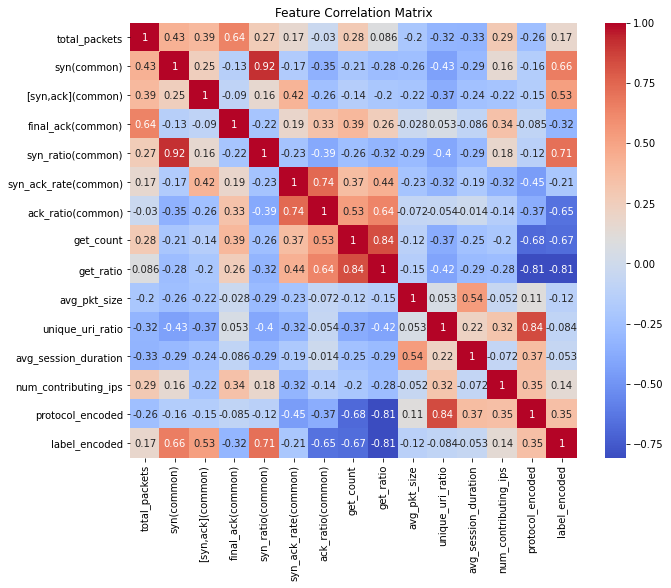

In [52]:
plt.figure(figsize=(10, 8))
sns.heatmap(dt.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.show()

In [53]:
cor_matrix = dt.corr().abs()
upper_tri = cor_matrix.where(np.triu(np.ones(cor_matrix.shape), k=1).astype(bool))
high_corr_pairs = [(col, row) for col in upper_tri.columns for row in upper_tri.index if upper_tri.loc[row, col] > 0.9]
print(high_corr_pairs)

[('syn_ratio(common)', 'syn(common)')]


In [54]:
dt = dt.drop(["syn(common)"], axis=1)
dt.shape

(2045, 14)

# Zero Values Check

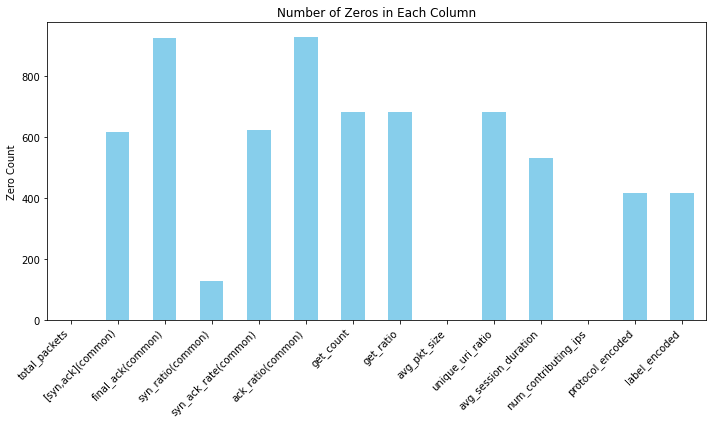

In [55]:
zero_counts = (dt == 0).sum()
plt.figure(figsize=(10, 6))
zero_counts.plot(kind='bar', color='skyblue')
plt.title("Number of Zeros in Each Column")
plt.ylabel("Zero Count")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [56]:
zero_percentage = (dt == 0).sum() / len(dt) * 100
zero_percentage = zero_percentage.sort_values(ascending=False)

print(zero_percentage)

ack_ratio(common)       45.525672
final_ack(common)       45.330073
get_count               33.398533
get_ratio               33.398533
unique_uri_ratio        33.398533
syn_ack_rate(common)    30.513447
[syn,ack](common)       30.268949
avg_session_duration    26.014670
protocol_encoded        20.391198
label_encoded           20.391198
syn_ratio(common)        6.308068
total_packets            0.000000
avg_pkt_size             0.000000
num_contributing_ips     0.000000
dtype: float64


In [57]:
dt.shape

(2045, 14)

In [72]:
dt.head()

,total_packets,"[syn,ack](common)",final_ack(common),syn_ratio(common),syn_ack_rate(common),ack_ratio(common),get_count,get_ratio,avg_pkt_size,unique_uri_ratio,avg_session_duration,num_contributing_ips,protocol_encoded,label_encoded
0,4,0,0,0.0,0.0,0.0,0,0.0,103.00,0.0,0.338,2,1,1
1,25,0,0,0.0,0.0,0.0,0,0.0,400.92,0.0,0.986,2,1,1
2,22,0,0,0.0,0.0,0.0,0,0.0,115.41,0.0,2.186,2,1,1
3,22,0,0,0.0,0.0,0.0,0,0.0,195.50,0.0,3.014,2,1,1
4,20,1,0,0.0,0.0,0.0,0,0.0,790.65,0.0,3.259,2,1,1


# Data Model Preparation

In [58]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import StandardScaler

In [59]:
X = dt.drop(["label_encoded"],axis = 1)
y = dt["label_encoded"]

print(f"X {X.shape}")
print(f"y {y.shape}")

X (2045, 13)
y (2045,)


In [60]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)

In [61]:
print(f"X train {X_train.shape}")
print(f"X test {X_test.shape}")
print(f"y train {y_train.shape}")
print(f"y test {y_test.shape}")

X train (1636, 13)
X test (409, 13)
y train (1636,)
y test (409,)


In [96]:
scaler = StandardScaler() 

In [97]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Random Forest

In [98]:
from sklearn.ensemble import RandomForestClassifier

In [99]:
random_model = RandomForestClassifier()
random_model.fit(X_train_scaled, y_train)

RandomForestClassifier()

In [101]:
y_pred = random_model.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        83
           1       1.00      1.00      1.00       215
           2       1.00      1.00      1.00       111

    accuracy                           1.00       409
   macro avg       1.00      1.00      1.00       409
weighted avg       1.00      1.00      1.00       409



# SVC Model

In [102]:
from sklearn.svm import SVC

In [103]:
svc_model = SVC() 
svc_model.fit(X_train_scaled, y_train)

SVC()

In [104]:
y_pred = svc_model.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        83
           1       1.00      1.00      1.00       215
           2       1.00      1.00      1.00       111

    accuracy                           1.00       409
   macro avg       1.00      1.00      1.00       409
weighted avg       1.00      1.00      1.00       409



# KNN Model

In [105]:
from sklearn.neighbors import KNeighborsClassifier

In [106]:
knn_model = KNeighborsClassifier(n_neighbors=5) 
knn_model.fit(X_train_scaled, y_train)

KNeighborsClassifier()

In [107]:
y_pred = knn_model.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        83
           1       1.00      1.00      1.00       215
           2       1.00      1.00      1.00       111

    accuracy                           1.00       409
   macro avg       1.00      1.00      1.00       409
weighted avg       1.00      1.00      1.00       409



# Decision Tree

In [108]:
from sklearn.tree import DecisionTreeClassifier

In [113]:
tree_model = DecisionTreeClassifier(random_state=42)
tree_model.fit(X_train_scaled, y_train)

DecisionTreeClassifier(random_state=42)

In [114]:
y_pred = tree_model.predict(X_test_scaled)
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Decision Tree Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        83
           1       1.00      1.00      1.00       215
           2       1.00      1.00      1.00       111

    accuracy                           1.00       409
   macro avg       1.00      1.00      1.00       409
weighted avg       1.00      1.00      1.00       409



# Prediction Sample

In [115]:
sample = [[4, 0, 0, 0.0, 0.0, 0.0, 0, 0.0, 103.00, 0.0, 0.338, 2, 1]]
#sample = [[25,0,0,0.0,0.0,0.0,0,0.0,400.92,0.0,0.986,2,1]]
sample_scaled = scaler.transform(sample)

In [116]:
knn_prediction = knn_model.predict(sample_scaled)
svc_prediction = svc_model.predict(sample_scaled)
random_prediction = random_model.predict(sample_scaled)
random_prediction_raw = random_model.predict(sample)
tree_prediction = tree_model.predict(sample_scaled)
tree_prediction_raw = tree_model.predict(sample)


print("Random Forest Predicted Class: ",random_prediction[0])
print("Random Forest Raw Predicted Class: ",random_prediction_raw[0])
print("Decision Tree Predicted Class:", tree_prediction[0])
print("Decision Tree Raw Predicted Class:", tree_prediction_raw[0])
print("KNN Predicted class: ",knn_prediction[0])
print("SVC Predicted Class: ",svc_prediction[0])

Random Forest Predicted Class:  1
Random Forest Raw Predicted Class:  1
Decision Tree Predicted Class: 1
Decision Tree Raw Predicted Class: 1
KNN Predicted class:  1
SVC Predicted Class:  1
